In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

def vegards_law(
    a_A,
    a_B,
    x,
    b=None
):
    """
    Interpolate between materials
    Lattice constant calculator

    https://en.wikipedia.org/wiki/Vegard%27s_law
    a_(A_(1-x)B_x) = (1-x) a_A + x a_B

    Use b for bandgap bowing parameter
    """
    if b is None:
        return (1-x) * a_A + x * a_B
    else:
        return (1-x) * a_A + x * a_B - b * x * (1 - x)

def plot_bandgap_lattice_constant(
    semiconductor_data='../data/semiconductors.csv',
    ax=None
):
    """
    PLot semiconductor bandgaps vs lattice constants
    
    TODO-TD: Use vegards_law to interpolate alloys with 
    Vurgaftman 2001
    Band parameters for III-V compound semiconductors and their alloys
    """
    df = pd.read_csv(semiconductor_data)
    df['Bandgap (Eg)'] = df['Bandgap (Eg)'].str.replace(' eV', '').astype(float)

    color_dict = {
        'Diamond (FCC)': 'red',
        'Zinc blende (FCC)': 'blue',
        'Wurtzite': 'green',
    }
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    for structure, color in color_dict.items():
        subset = df[df['Crystal Structure'] == structure]
        ax.scatter(
            subset['a (A)'],
            subset['Bandgap (Eg)'],
            color=color,
            s=50,
            label=structure
        )

    for _, row in df.iterrows():
        ax.annotate(
            row['Material'],
            (row['a (A)'], row['Bandgap (Eg)']),
            textcoords="offset points",
            xytext=(0, 10)
        )

    ax.legend(title="Crystal Structure")
    plt.title('Semiconductor Bandgap vs. Lattice Constant (a)')
    plt.xlabel('Lattice Constant a (A)')
    plt.ylabel('Bandgap $E_g$ (eV)')
    plt.grid(ls='--', alpha=0.3)
    plt.tight_layout()
    return ax


<Axes: title={'center': 'Semiconductor Bandgap vs. Lattice Constant (a)'}, xlabel='Lattice Constant a (A)', ylabel='Bandgap $E_g$ (eV)'>

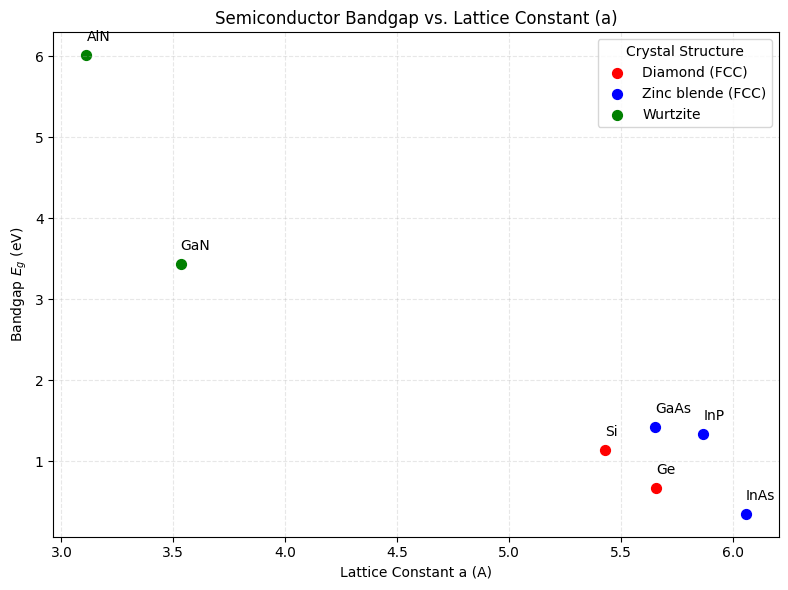

In [ ]:
ax = plot_bandgap_lattice_constant()


# TODO-TD: try Ga_0.5In_0.5As

ax.scatter()
plt.show()

In [7]:
# 'Ga_0.5In_0.5P' => 0.5 GaP and 0.5 InP?